# WILDFIRE RISK AND SEVERITY ANALYSIS

## BUSINESS UNDERSTANDING

### Project Problem Statement
Wildfires can cause serious damage to forests, property, and human life. Understanding the weather and environmental conditions that influence wildfire occurrence and severity can help improve preparation and response efforts to reduce wildfire risk and damage.

## Project Objective:
To explore environmental conditions that influence wildfire occurrence and severity. 

### Project Goal:
Understand how temperature, humidity, wind, and rainfall affect wildfire risk. 
Identify patterns that can support better wildfire preparedness and response.

## DATA UNDERSTANDING

Here, I explored the dataset to understand what it contains and check its quality before cleaning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading And Preview Of The Dataset 

In [3]:
df = pd.read_csv("../data/forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [4]:
df = pd.read_csv("../data/forestfires.csv")
df.tail()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00


In [5]:
df.shape

(517, 13)

#### Dataset Structure

In [6]:
df.dtypes

X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

#### Checking For Missing Values

In [ ]:
df.isnull().sum()

#### Understanding Variables In The Dataset

| Column | Meaning |
|---|---|
| X | x-axis spatial coordinate of the forest fire location |
| Y | y-axis spatial coordinate of the forest fire location |
| month | month the fire incident occurred |
| day | day of the week the fire incident occurred |
| FFMC | Fine Fuel Moisture Code |
| DMC | Duff Moisture Code |
| DC | Drought Code |
| ISI | Initial Spread Index |
| temp | temperature in °C |
| RH | relative humidity (%) |
| wind | wind speed |
| rain | rainfall amount |
| area | burned forest area |

#### Data Overview

The dataset has 517 rows and 13 columns. It includes both categorical and numerical variables related to forest fire conditions, weather, and burned area.The dataset appears structured and suitable for analysis.

#### Dataset Observation

- The dataset is clean and well-structured.
- No missing values were found.
- Most variables are numerical.
- 'month' and 'day' are categorical variables.
- 'area' appears to be the main variable of interest for analysis.

## DATA PREPARATION

Checking for duplicates

In [7]:
import pandas as pd
df = pd.read_csv("../data/forestfires.csv")
df.duplicated().sum()

np.int64(4)

In [8]:
# Displaying The Original and duplicated rows
df[df.duplicated(keep=False)]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


#### Duplicate Check

A total of 4 duplicate rows were identified in the dataset. Since these rows were exact copies of existing records, they were removed to improve data quality and prevent duplicate observations from affecting the analysis.

In [9]:
# Removing duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
# Recomfirming For Missing Values

df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [11]:
# Checking For Inconsistencies in Categorical Columns
# For Day
df["day"].unique()

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

In [12]:
# For Month
df["month"].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [14]:
# Fixing Month Ordering
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

In [15]:
# Fixing Day Ordering
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df["day"] = pd.Categorical(df["day"], categories=day_order, ordered=True)

#### Checking Categorical Columns

I checked the categorical columns using their unique values to make sure there were no spelling or formatting issues. The month and day columns were consistent, so I converted them into ordered categories to keep their correct calendar order during analysis.

In [16]:
# Saving Copy of Cleaned Dataset
df_cleaned = df.copy()

#### Cleaned Dataset

A cleaned copy of the dataset was created and saved as'df_cleaned" for use in the next stage of analysis.

## Understanding The Target Variable

In this section, I examined the `area` column, which shows the total burned area caused by each fire. Since this is the value the model will predict, I checked its distribution and looked for extreme values before moving to modeling.

In [17]:
df['area'].describe()

count     513.000000
mean       12.891598
std        63.892586
min         0.000000
25%         0.000000
50%         0.540000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

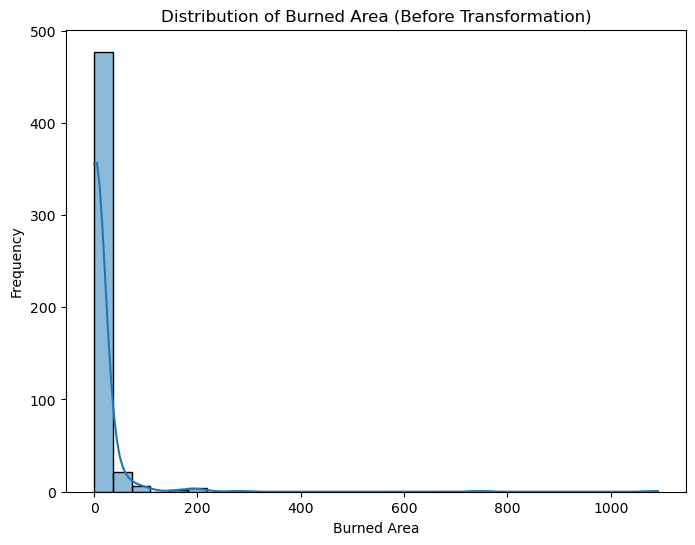

In [18]:
# Visualization of Target Variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df['area'], bins=30, kde=True)
plt.title('Distribution of Burned Area (Before Transformation)')
plt.xlabel('Burned Area')
plt.ylabel('Frequency')
plt.show()

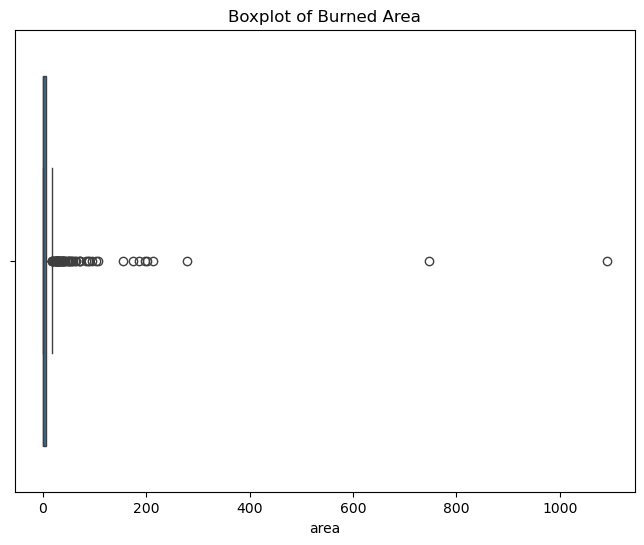

In [19]:
# Checking For Outliers (Extreme Values that deviate significantly from the rest of a dataset in a distribution)
plt.figure(figsize=(8,6))
sns.boxplot(x=df['area'])
plt.title('Boxplot of Burned Area')
plt.show()

In [20]:
# Inspecting Skewness Of Burnt Area

df["area"].skew()

np.float64(12.802213419146321)

#### Skewness in Burned Area

The area column is heavily skewed to the right, with a skewness value of 12.80. This means most fires burned only small areas, while a few spread across much larger areas.

#### Burned Area Distribution Assessment

The burned area column was examined in more detail because it is the main variable being predicted in this project.

In [21]:
# Finding records with zero burned area
(df["area"] == 0).sum()

np.int64(244)

In [22]:
# Most frequent values in the area column
df["area"].value_counts().head()

area
0.00     244
1.94       3
1.46       2
9.96       2
11.06      2
Name: count, dtype: int64

#### Observation 

The burned area column contains many zero values, and most of the remaining values are relatively small compared to the few large ones.

#### Separation of Burned Area Into Groups

To better understand the nature of zero burned area records, the dataset is divided into:
- Fire events with no recorded burned area (`area = 0`)
- Fire events with measurable burned area (`area > 0`)

In [23]:
# Sectionining Of Area Column Into Groups
zero_area = df[df['area'] == 0]
non_zero_area = df[df['area'] > 0]

print("Zero area count:", len(zero_area))
print("Non-zero area count:", len(non_zero_area))

Zero area count: 244
Non-zero area count: 269


#### Comparison of Fire Weather Conditions

To better understand the records with zero burned area, fire weather conditions were compared between observations with no burned area and those with recorded burned area. This helps to check whether both groups were exposed to similar environmental conditions and whether the zero values are meaningful for further analysis.

The fire weather indices (FFMC, DMC, DC, and ISI) describe how favorable the conditions are for fire ignition and spread, regardless of the final burned area.

In [24]:
indices = ['FFMC', 'DMC', 'DC', 'ISI']

comparison = df.groupby(df['area'] == 0)[indices].mean()
comparison.index = ['Non-Zero Area', 'Zero Area']

comparison

,FFMC,DMC,DC,ISI
Non-Zero Area,91.031599,115.001115,572.688848,9.182156
Zero Area,90.202869,106.566393,523.210246,8.848770


Fire weather indices were compared between zero burned area records and non-zero burned area records.

The results show that both groups have similar values, although the non-zero burned area group is slightly higher across most indices. This suggests that fires with and without burned area often occur under similar weather conditions.

Overall, this supports keeping the zero burned area records in the dataset, since they still occur under similar fire weather conditions 

## Distribution Comparison of Fire Weather Indices

Boxplots was used to visually compare fire weather conditions between zero and non-zero burned area events.

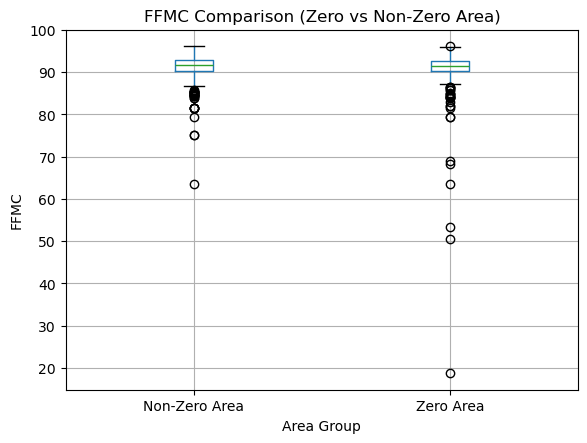

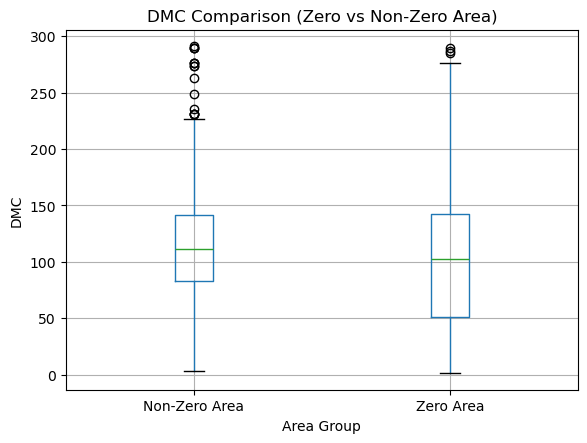

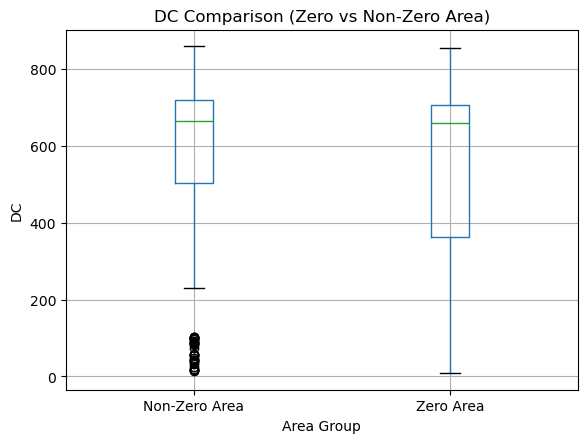

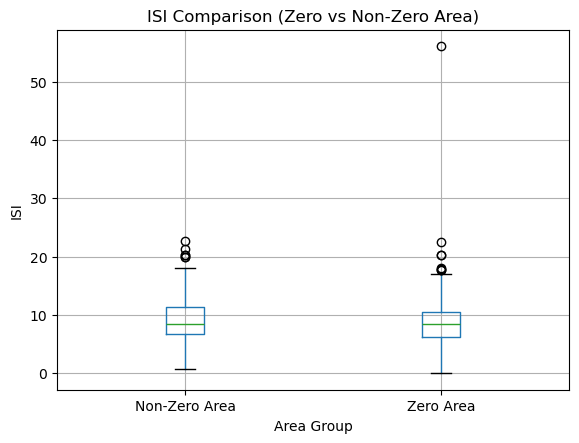

In [25]:
# creating grouping column
df['area_group'] = df['area'].apply(lambda x: 'Zero Area' if x == 0 else 'Non-Zero Area')

import matplotlib.pyplot as plt

for col in indices:
    df.boxplot(column=col, by='area_group')
    plt.title(f'{col} Comparison (Zero vs Non-Zero Area)')
    plt.suptitle("")
    plt.xlabel("Area Group")
    plt.ylabel(col)
    plt.show()

In [44]:
# Target Variable Log Transformation
import numpy as np

df_clean = df.copy()
df_clean['area_log'] = np.log1p(df_clean['area'])

In [40]:
# Updating Cleaned Dataset With Newly added Column(area_log)

df_cleaned.to_csv('cleaned_forestfires.csv', index=False)

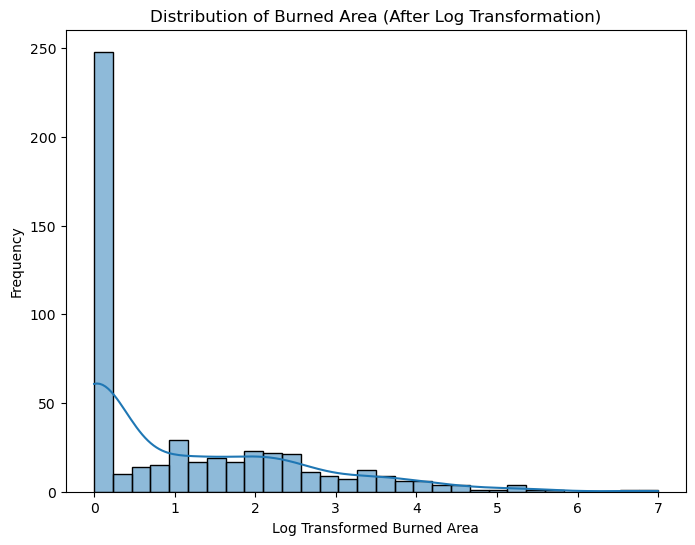

In [32]:
# Visualizing Transformed Target Variable

plt.figure(figsize=(8,6))
sns.histplot(df_cleaned['area_log'], bins=30, kde=True)
plt.title('Distribution of Burned Area (After Log Transformation)')
plt.xlabel('Log Transformed Burned Area')
plt.ylabel('Frequency')
plt.show()

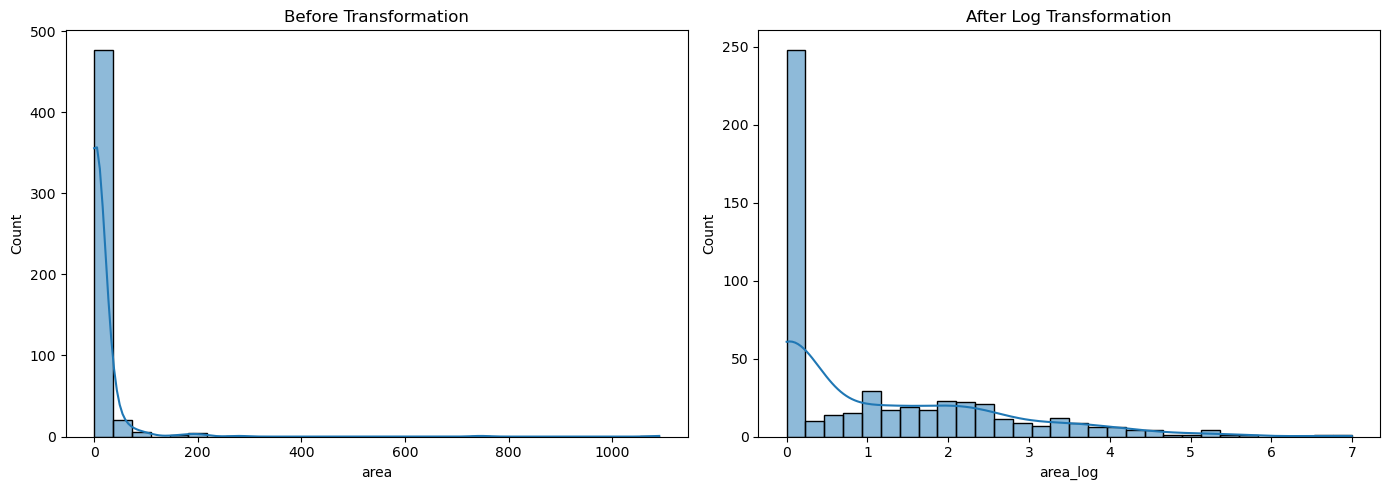

In [45]:
# Comparison of the before and after of the target Variable
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['area'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Before Transformation')

sns.histplot(df_clean['area_log'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('After Log Transformation')

plt.tight_layout()
plt.show()

#### Preparing the Target Variable

The area column was heavily skewed, with many small values and a few very large ones. This made the distribution uneven and could affect model performance.

To reduce this skewness and limit the effect of extreme values, I applied a log transformation (log1p) to the area column.

This made the distribution more balanced and better suited for further analysis and modeling.

In [46]:
# LOADING UPDATED CLEANED DATASET

import pandas as pd

df_cleaned = pd.read_csv('cleaned_forestfires.csv')
df_cleaned.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_log
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0


## EXPLORATORY DATA ANALYSIS

### Exploring Weather Relationships

How temperature and humidity relates to wildfire burned area is examined.The goal is to identify whether these weather conditions show any visible pattern with how much land gets burned (area).

#### Temperature vs Burned Area

Are higher temperatures linked with larger wildfire burned areas?

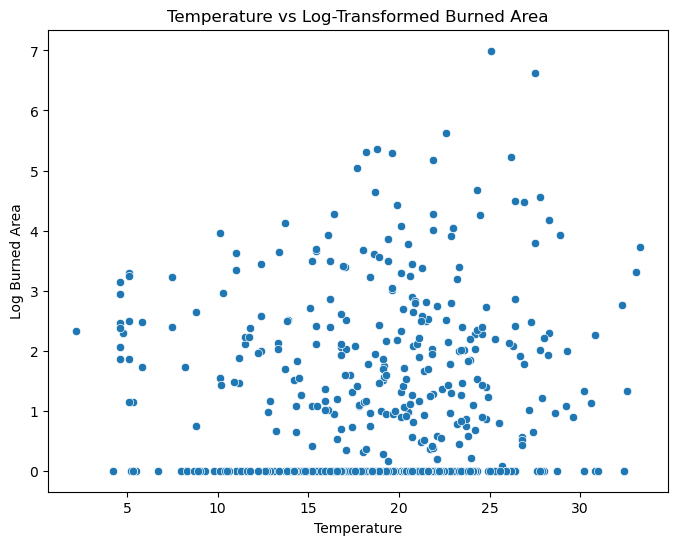

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='temp', y='area_log')
plt.title('Temperature vs Log-Transformed Burned Area')
plt.xlabel('Temperature')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot suggests a weak positive relationship between temperature and burned area. Most wildfire events are concentrated around lower burned area values, meaning many fires remained relatively small. However, a few larger wildfire events appear more often at moderate to higher temperatures, suggesting that warmer conditions may be linked to larger wildfires. 

#### Insight

This suggests that temperature may influence wildfire spread, as warmer conditions may support larger fires. The use of the log-transformed burned area also helps reduce the effect of extreme wildfire events, making the overall relationship clearer and easier to analyze.

#### Humidity vs Burned Area

Do humidity levels influence wildfire burned area?

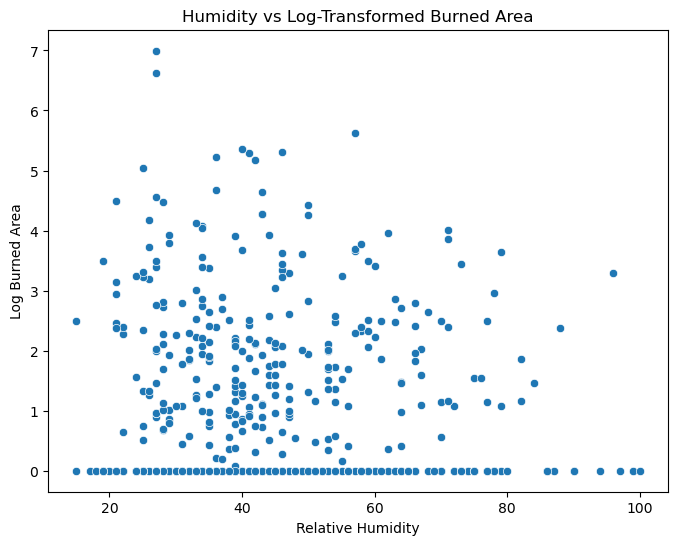

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='RH', y='area_log')
plt.title('Humidity vs Log-Transformed Burned Area')
plt.xlabel('Relative Humidity')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a slight negative relationship between humidity and burned area. Wildfire events are mostly clustered around smaller burned areas, even across different humidity levels. Still, a few larger fires appear when humidity is lower, which suggests that drier air may be linked to wider wildfire spread.

#### Insight

This suggests that humidity may influence wildfire area size, especially under drier conditions. Lower humidity can make vegetation lose moisture more easily, which may allow fires to spread faster. Although, humidity alone does not explain wildfire size, which means other factors likely also contribute to how much land gets burned. 

#### Wind vs Burned Area

Does wind speed influence wildfire burned area?

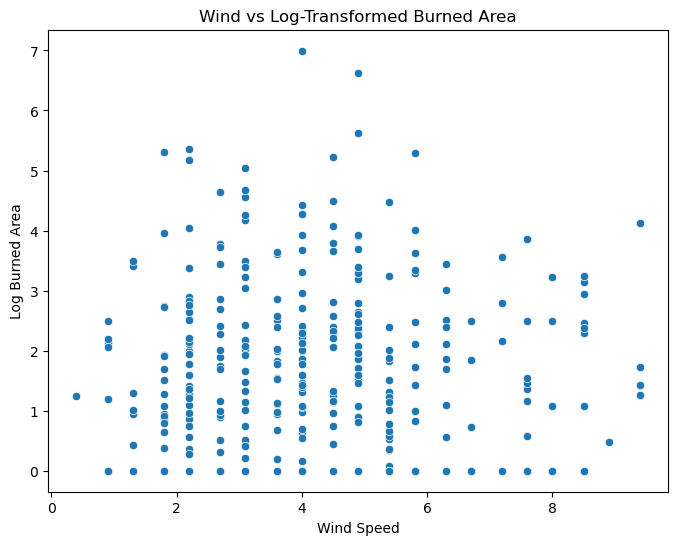

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='wind', y='area_log')
plt.title('Wind vs Log-Transformed Burned Area')
plt.xlabel('Wind Speed')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a weak relationship between wind speed and log-transformed burned area. Wildfire events are mostly clustered around lower burned area values across different wind speeds, meaning many fires remained relatively small. A few larger wildfire events appear at moderate wind speeds, which indicates that wind may support wildfire spread under certain conditions.

#### Insight

Wind speed may influence how quickly wildfires spread, especially when conditions are favorable for fire movement. However, the pattern in the chart also shows that wind alone is not enough to explain wildfire size, since many wildfire events still remained small across different wind speeds.

## Rainfall vs Burned Area

Can Rainfall influence wildfire burned area?

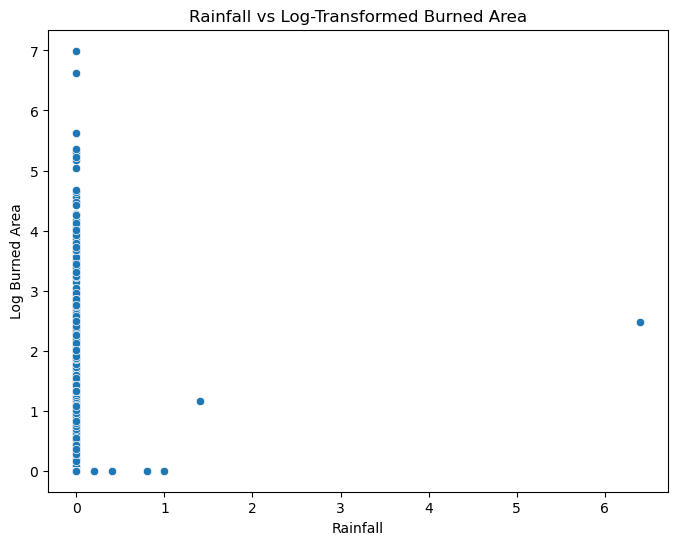

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='rain', y='area_log')
plt.title('Rainfall vs Log-Transformed Burned Area')
plt.xlabel('Rainfall')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a very weak relationship between rainfall and log-transformed burned area. Most wildfire events occurred under little or no rainfall, while burned area values still varied across these conditions. The points are widely spread, making the relationship less clear and showing that rainfall alone does not strongly explain wildfire burned area in the dataset.

#### Insight

Most wildfire events in the dataset happened during low rainfall conditions. However, both small and larger wildfire events still occurred when rainfall was low, which shows that rainfall alone is not enough to explain wildfire burned area. Other environmental factors likely also affect how much land gets burned.

## Seasonal Wildfire Trend 

Wildfire timing patterns iwill be checked by examining wildfire frequency across months and days, as well as burned area trends by month. This helps identify possible seasonal patterns in wildfire activity.

#### Fires by Month

Which month recorded the highest number of wildfire events?

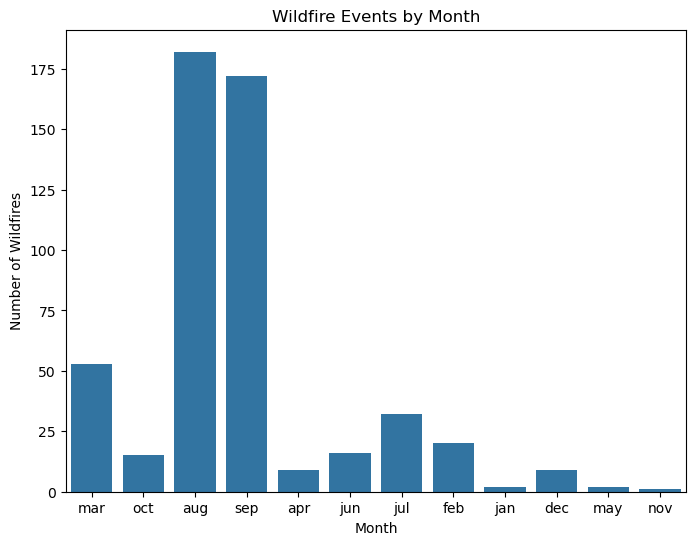

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(data=df_cleaned, x='month')
plt.title('Wildfire Events by Month')
plt.xlabel('Month')
plt.ylabel('Number of Wildfires')
plt.show()

#### Interpretation

The chart above shows that wildfire events were not evenly distributed across the months. August and September recorded the highest number of wildfire events, while some months such as November, May, and January recorded very few wildfire occurrences. This pattern indicates that wildfire activity was more concentrated during certain periods of the year.

#### Insight

This indicates that wildfire activity may increase during specific seasons, particularly around late summer periods such as August and September. Environmental conditions during these months, such as higher temperatures and drier conditions, may contribute to increased wildfire occurrence.

### Fires by Day

What days recorded more wildfire events?

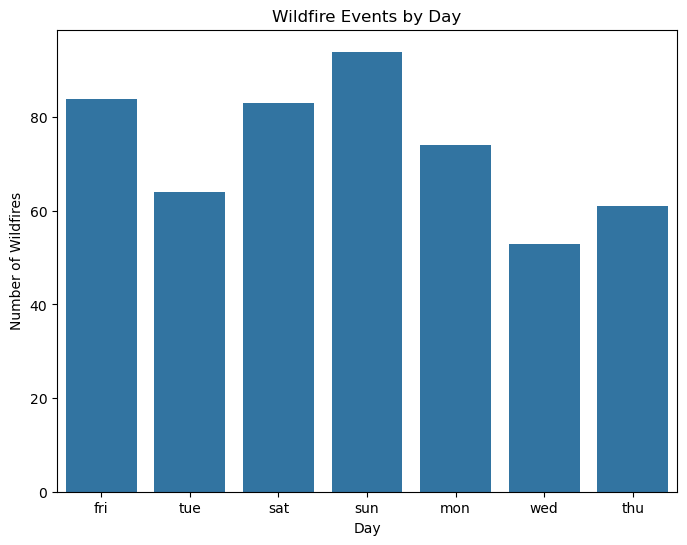

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(data=df_cleaned, x='day')
plt.title('Wildfire Events by Day')
plt.xlabel('Day')
plt.ylabel('Number of Wildfires')
plt.show()

#### Interpretation

The chart shows variations in wildfire frequency across different days of the week. Sunday recorded the highest number of wildfire events, while Wednesday recorded the lowest. Although wildfire events occurred throughout the week, some days experienced slightly higher wildfire activity than others.

#### Insight

This indicates that wildfire occurrences may vary across the week, but the differences are not extremely large. The pattern suggests that wildfire activity is not strongly concentrated on a single day, as wildfire events were recorded consistently throughout the week.

#### Wildfire Severity by Month

What month experienced larger wildfire burned areas?

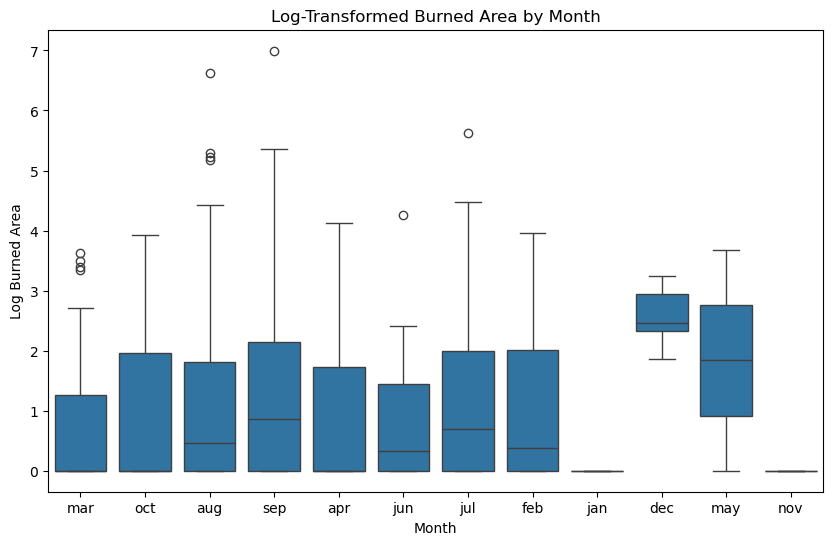

In [53]:
import matplotlib.pyplot as lt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=df_cleaned, x='month', y='area_log')
plt.title('Log-Transformed Burned Area by Month')
plt.xlabel('Month')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation
The box plot shows differences in log-transformed burned area across the months. Months such as September, July, and August recorded higher burned area values and greater variation compared to some other months. December also shows relatively higher median burned area values, although with fewer extreme values. In contrast, months like January and November recorded little or no burned area activity. The presence of outliers in some months indicates that a few wildfire events resulted in unusually large burned areas.

#### Insight

This indicates that wildfire severity varied across different months of the year. Months with higher burned area values and wider distributions may have experienced environmental conditions that supported larger wildfire spread. 

##  FEATURE ENGINEERING (Creating New Variables)

Feature engineering was carried out to create new variables that can help improve wildfire risk analysis and make patterns in the data easier to understand. The new features were created from existing weather and wildfire variables to help identify conditions linked to wildfire risk and fire severity.

### High Risk Condition Flag

This variable was created to identify weather conditions that may increase the chances of wildfire occurrence.

In [54]:
# Wildfire occurence is high risk if:
df_cleaned["high_risk"] = (
    (df_cleaned["temp"] >= 28) &
    (df_cleaned["wind"] >= 4) &
    (df_cleaned["RH"] <= 45))
df_cleaned[["temp", "wind", "RH", "high_risk"]].head()

,temp,wind,RH,high_risk
0,8.2,6.7,51,False
1,18.0,0.9,33,False
2,14.6,1.3,33,False
3,8.3,4.0,97,False
4,11.4,1.8,99,False


The high-risk wildfire condition feature was created using weather thresholds associated with Mediterranean wildfire behavior in Portugal.

A condition is classified as high risk when:
- temperature was at least 28°C and above,
- wind speed was at least 4 km/h and above,
- relative humidity was 45% or lower.

These thresholds were selected because hot temperatures, stronger winds, and low humidity can dry out vegetation and make wildfire spread more likely.

In [55]:
# High Risk Condtion Distribution

df_cleaned["high_risk"].value_counts()

high_risk
False    500
True      13
Name: count, dtype: int64

#### Interpretation
The distribution of the high-risk feature shows that most wildfire observations were classified as low risk, while only a small number met the high-risk condition criteria.

Out of 517 observations:
- 504 were classified as low risk
- 13 were classified as high risk

#### Insight
This suggests that extreme wildfire weather conditions were not very common in the dataset.

### Fire Size Category
This was created to to group wildfire incidents into small and large fire categories based on the burned area. The median burned area was used as the classification threshold because the burned area data is highly skewed.

This feature improves interpretability by simplifying wildfire severity into meaningful categories that can be analyzed more easily.

In [58]:
# use of median because of the skewedness of the dataset
median_area = df_cleaned["area"].median()

In [57]:
# Fire Size Category of dataset
df_cleaned["fire_size"] = df_cleaned["area"].apply(
    lambda x: "Large Fire" if x > median_area else "Small Fire")
df_cleaned [["area", "fire_size"]].head()

,area,fire_size
0,0.0,Small Fire
1,0.0,Small Fire
2,0.0,Small Fire
3,0.0,Small Fire
4,0.0,Small Fire


In [59]:
# Fire Size Condtion Distribution

df_cleaned["fire_size"].value_counts()

fire_size
Small Fire    257
Large Fire    256
Name: count, dtype: int64

### Interpretation
Out of 517 observations:
- 259 were classified as Small Fire
- 258 were classified as Large Fire

This balanced distribution occurred because the median burned area was used as the classification threshold. 

### Insight
The result shows that the feature created a clear separation between small and large fires, making wildfire severity easier to analyse.

### Feature Engineering Summary

Two new features were created during this stage:
- High_risk → identifies weather conditions linked to wildfire risk
- Fire_size → groups wildfire incidents into small and large fires

These features help improve wildfire interpretation and can support future predictive modelling.

In [60]:
# Saving Updated Dataset With The newly created features

df_cleaned.to_csv("df_cleaned.csv", index=False)

## MODELLING PREPARATION

In this section, the cleaned dataset was prepared for modelling. The target variable and feature columns were selected,and the data was split into training and testing sets.

In [61]:
# loading Cleaned Dataset new columns created inclusive

import pandas as pd
df_cleaned.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_log,high_risk,fire_size
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0,False,Small Fire
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0,False,Small Fire
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0,False,Small Fire
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0,False,Small Fire
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0,False,Small Fire


In [62]:
# Defining the Target Variable for the model
y = df_cleaned["fire_size"]

In [63]:
# Removing area, area_log columns as it is the target variable to prevent data leakage during modeling

X = df_cleaned.drop(["area", "area_log", "fire_size"], axis=1)

In [64]:
#checking dataset for text object

X.dtypes

X              int64
Y              int64
month         object
day           object
FFMC         float64
DMC          float64
DC           float64
ISI          float64
temp         float64
RH             int64
wind         float64
rain         float64
high_risk       bool
dtype: object

In [65]:
# Converting text to Numbers By Encoding Categorical Variables

X = pd.get_dummies(X, drop_first=True)

#### Train_Test Split

The dataset was divided into training and testing sets. 
80% of the data was used for training the model, while 20% was reserved for testing.

In [66]:
# Spliting dataset into training data and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

#### Checking Dataset Shape

The shapes of the training and testing datasets were checked to confirm that the data was split correctly.

In [67]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (410, 28)
X_test shape: (103, 28)
y_train shape: (410,)
y_test shape: (103,)


### Modelling Preparation Summary

The dataset was prepared for machine learning by defining the feature and target variables and splitting the data into training and testing sets.

The output shows that the dataset was successfully divided into training and testing sets. The training data contains 413 rows, while the testing data contains 104 rows. Both datasets contain 28 feature columns for modelling.

## MODELLING PHASE

In [68]:
# Importing libraries

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import numpy as np

### Building The Model

In [69]:
# Traing the Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Predict Wildfire_Size Category

In [70]:
y_pred = model.predict(X_test)

### Evaluation Of Model

In [71]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.5922330097087378
              precision    recall  f1-score   support

  Large Fire       0.56      0.56      0.56        48
  Small Fire       0.62      0.62      0.62        55

    accuracy                           0.59       103
   macro avg       0.59      0.59      0.59       103
weighted avg       0.59      0.59      0.59       103



### Model Evaluation Interpretation

The Decision Tree Classification model was used to predict whether a wildfire would be classified as a Small Fire or Large Fire based on environmental and weather conditions.

The model achieved an accuracy score of 56%, meaning it correctly classified wildfire size categories in about 56 out of every 100 cases.

For Large Fire prediction:

The model achieved a precision score of 0.54, showing that many of the predicted large fires were correctly identified. The recall score of 0.63 indicates that the model was able to detect a reasonable number of actual large fire cases.

For Small Fire prediction:

The precision score was 0.58, meaning the model performed slightly better when predicting small fires. However, the recall score of 0.49 suggests that some small fire cases were misclassified.

Overall, the model showed moderate performance in distinguishing between small and large wildfires. The results suggest that environmental conditions such as temperature, wind, humidity, and rainfall have some influence on wildfire severity, although wildfire behaviour remains difficult to predict accurately

## Model Performance

The model performance shows how well the classification model was able to distinguish between small and large wildfire incidents using environmental conditions.

An accuracy score of 56% indicates that the model performed slightly better than random guessing, meaning it was able to identify some wildfire patterns but still made several incorrect predictions.

The results suggest that factors such as temperature, wind speed, humidity, and rainfall have some relationship with wildfire severity, but they may not fully explain wildfire behaviour on their own.

Overall, the model demonstrates that wildfire prediction is a complex problem and that additional environmental variables or more advanced machine learning techniques may improve prediction performance.

# KEY INSIGHTS

1. Temperature and low humidity were linked to more severe wildfires:

The analysis showed that wildfire burned areas tended to increase during periods of higher temperature and lower humidity. Dry weather conditions appeared to support wildfire spread and intensity.

2. Rainfall had little influence on wildfire severity:

Most wildfire observations recorded very low rainfall values. This suggests that rainfall had minimal impact on reducing wildfire severity within the dataset.

3. Wildfire activity was higher during August and September:

The monthly wildfire analysis showed that August and September experienced the highest wildfire activity and larger burned areas. This indicates that wildfire risk may increase during hotter and drier periods of the year.

4. Wind conditions may contribute to wildfire spread:

The analysis suggested that stronger wind conditions may help wildfires spread more quickly across affected areas, although the relationship was not very strong.

5. High-risk environmental conditions were associated with wildfire occurrence:

The engineered high_risk feature showed that combinations of high temperature, strong wind, and low humidity may help identify weather conditions linked to increased wildfire risk.

6. Wildfire behaviour remained difficult to predict accurately:

Although the classification model was able to identify some wildfire patterns, the model performance showed that wildfire behaviour is complex and may depend on additional environmental and geographical factors not included in the dataset.

# Recommedndations

1. Increase wildfire monitoring during high-risk weather conditions: Wildfire monitoring efforts should be strengthened during periods of high temperature, low humidity, and stronger wind conditions to help reduce wildfire impact.

2. Develop early warning systems using environmental indicators: Environmental variables such as temperature, humidity, and wind speed can be used to support early wildfire warning systems and improve wildfire preparedness.

3. Allocate firefighting resources during peak wildfire periods: Since wildfire activity was higher during certain months, firefighting resources should be allocated more strategically during high-risk wildfire seasons.

4. Improve wildfire prediction models with additional environmental data: Future wildfire prediction models may perform better if additional variables such as vegetation type, drought conditions, and geographical information are included.

5. Promote public awareness during high-risk wildfire conditions: Public awareness campaigns can help communities understand dangerous wildfire conditions and encourage preventive safety measures during wildfire-prone periods.

# Conclusion

This project examined how environmental and weather conditions affect wildfire severity using the Portugal Forest Fires dataset.

From the analysis, factors such as high temperature, low humidity, wind conditions, and seasonal changes appeared to influence wildfire behaviour and burned area patterns.

Although the classification model showed only moderate performance, the project helped demonstrate how data analysis and machine learning can be used to better understand wildfire risk and support environmental decision-making.

Overall, the project provided useful insights into wildfire patterns and highlighted the importance of environmental monitoring during high-risk conditions